In [1]:
import os
os.chdir("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Oligo")
import glob
import dill
import mudata
import pyranges as pr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scenicplus.utils import get_interaction_pr
from scenicplus.networks import concentrical_layout, create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape

In [2]:
scplus_mdata = mudata.read("outs/scplusmdata.h5mu")
with open('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Oligo/outs/scplus_obj.pkl', 'rb') as f:
    scplus_obj = dill.load(f)

region_to_gene = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scenicplus/Oligo/outs/region_to_gene_adj.tsv",sep = '\t')
scplus_obj.uns['region_to_gene'] = region_to_gene.copy()

/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed i

In [3]:
scplus_mdata.uns['direct_e_regulon_metadata'][scplus_mdata.uns['direct_e_regulon_metadata']['Region_signature_name'].isin(scplus_mdata['direct_region_based_AUC'].var.index)]['TF'].unique()

array(['ASCL1', 'ATF7', 'BACH2', 'BHLHE41', 'CREB5', 'E2F7', 'ETV6',
       'EZH2', 'GLIS3', 'HOXA3', 'HOXB3', 'HOXD3', 'LCORL', 'MEIS2',
       'NFIA', 'NFIB', 'NKX6-2', 'NR2F1', 'OLIG2', 'PAX6', 'PAX7', 'PBX1',
       'POU2F2', 'RAD21', 'RFX3', 'RFX4', 'SOX10', 'SOX11', 'SOX2',
       'SOX5', 'SOX6', 'TCF12', 'TCF4', 'YBX1', 'ZBTB20', 'ELF1', 'FOXM1',
       'MXD3', 'NF1', 'ZNF536', 'E2F3', 'MEIS1', 'ZNF385D', 'ETV1',
       'HMGA2'], dtype=object)

https://github.com/aertslab/scenicplus/discussions/511

Region: predicted target region

Gene: predicted target gene

importance_R2G: importance score of region-to-gene link (from GRNBoost)

rho_R2G: correlation coefficient of region-to-gene link

importance_x_rho: the product of the previous two columns

importance_x_abs_rho: the product of the previous two columns, but the absolute value of rho_R2G is taken

TF: TF name

is_extended: wether the motif-to-TF annotation is from direct evidence or not (i.e. orthology or similarity based)

eRegulon_name: regulon name

Gene_signature_name: gene signature name

Region_signature_name: region signature name

importance_TF2G: TF-to-gene importance score (grn boost)

regulation: wether the interaction is activating or repressive

rho_TF2G: TF-to-gene correlation coefficient

triplet_rank: Triplet rank score (see paper for detailed explanation)

In [4]:
scplus_mdata.uns['direct_e_regulon_metadata']['eRegulon_name'].value_counts()

NFIA_direct_+/+       2929
NFIB_direct_+/+       2559
TCF12_direct_+/-      2106
RFX3_direct_+/+       1798
RFX4_direct_+/+       1785
                      ... 
SOX5_direct_-/-         20
BHLHE41_direct_+/+      14
TCF4_direct_-/-         13
HOXA3_direct_+/+        12
FOXM1_direct_+/-        12
Name: eRegulon_name, Length: 70, dtype: int64

In [5]:
network = scplus_mdata.uns['direct_e_regulon_metadata'].loc[scplus_mdata.uns['direct_e_regulon_metadata']['eRegulon_name'].isin(['OLIG2_direct_+/+', 'SOX5_direct_+/-', 'SOX6_direct_+/-', 'TCF4_direct_+/+']) ,:]
network

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
8872,chr2:172861593-172862094,RAPGEF4,0.124976,0.503759,0.062958,0.062958,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(82g),OLIG2_direct_+/+_(105r),0.453730,1,0.246115,7458
8873,chr12:49809998-49810499,FMNL3,0.082771,0.085582,0.007084,0.007084,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(82g),OLIG2_direct_+/+_(105r),0.581693,1,0.112418,22982
8874,chr12:104742498-104742999,CHST11,0.061474,0.478037,0.029387,0.029387,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(82g),OLIG2_direct_+/+_(105r),1.381980,1,0.262042,8636
8875,chr7:153943746-153944247,DPP6,0.039082,0.624387,0.024403,0.024403,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(82g),OLIG2_direct_+/+_(105r),0.682059,1,0.325589,29205
8876,chr2:158998723-158999224,TANC1,0.159490,0.539579,0.086058,0.086058,OLIG2,False,OLIG2_direct_+/+,OLIG2_direct_+/+_(82g),OLIG2_direct_+/+_(105r),0.346731,1,0.177793,6909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26023,chr20:15795281-15795782,MACROD2,0.003089,-0.066303,-0.000205,0.000205,SOX6,False,SOX6_direct_+/-,SOX6_direct_+/-_(310g),SOX6_direct_+/-_(496r),6.512207,1,0.482583,459
26024,chr18:48545619-48546120,CTIF,0.014791,-0.098145,-0.001452,0.001452,SOX6,False,SOX6_direct_+/-,SOX6_direct_+/-_(310g),SOX6_direct_+/-_(496r),1.471757,1,0.182074,2340
26025,chr15:64093722-64094223,SNX1,0.026620,-0.135687,-0.003612,0.003612,SOX6,False,SOX6_direct_+/-,SOX6_direct_+/-_(310g),SOX6_direct_+/-_(496r),4.018514,1,0.286013,7287
26026,chr7:8387607-8388108,NXPH1,0.046590,-0.296101,-0.013795,0.013795,SOX6,False,SOX6_direct_+/-,SOX6_direct_+/-_(310g),SOX6_direct_+/-_(496r),3.866891,1,0.418044,4578


In [6]:
network['Region'].value_counts()

chr7:23299035-23299536      6
chr14:51989257-51989758     5
chr1:231021601-231022102    4
chr16:1019385-1019886       4
chr2:127651764-127652265    4
                           ..
chr13:34933757-34934258     1
chr1:41783080-41783581      1
chr16:7533312-7533813       1
chr1:240038001-240038502    1
chr5:10124261-10124762      1
Name: Region, Length: 1323, dtype: int64

In [7]:
scplus_obj.X_ACC #141240 rows × 9282 columns
scplus_obj.X_EXP #9282 rows × 36601 columns
scplus_obj.uns.keys() #dict_keys(['eRegulon_metadata', 'eRegulon_AUC', 'eRegulons'])
scplus_obj.uns['eRegulon_AUC'].keys() #dict_keys(['Gene_based', 'Region_based'])
scplus_obj.uns['eRegulon_AUC']['Gene_based'] #9282 rows × 119 columns
scplus_obj.uns['eRegulon_AUC']['Region_based'] #9282 rows × 119 columns

,ASCL1_direct_+/+_(94r),ATF7_direct_+/+_(249r),BACH2_direct_+/+_(97r),BHLHE41_direct_+/+_(14r),CREB5_direct_+/+_(264r),E2F3_direct_-/+_(34r),E2F7_direct_+/+_(641r),E2F7_direct_+/-_(180r),ELF1_direct_+/-_(225r),ETV1_direct_-/-_(47r),...,SOX5_extended_+/-_(466r),SOX5_extended_-/+_(320r),SOX5_extended_-/-_(11r),SOX6_extended_+/+_(422r),SOX6_extended_+/-_(314r),SOX6_extended_-/+_(266r),TCF12_extended_+/+_(665r),TCF12_extended_+/-_(706r),TCF4_extended_+/+_(508r),TCF7L2_extended_+/-_(49r)
Cell,,,,,,,,,,,,,,,,,,,,,
TCGTTTCCAACTCGCG-1-7___cisTopic,0.006860,0.200081,0.166884,0.067100,0.209652,0.131370,0.046881,0.154295,0.072926,0.079885,...,0.067021,0.069800,0.000000,0.045865,0.043243,0.077571,0.053275,0.010860,0.007377,0.008369
CCTCCTGAGTTAGTTG-1-7___cisTopic,0.034782,0.127766,0.092686,0.075495,0.122708,0.108451,0.065591,0.137899,0.114661,0.143423,...,0.061782,0.020912,0.057362,0.046241,0.039741,0.023807,0.023684,0.026663,0.031607,0.013542
CGTCCTAGTAACCTAG-1-1___cisTopic,0.055843,0.123689,0.127507,0.028422,0.132559,0.065858,0.041529,0.160728,0.096066,0.098956,...,0.059015,0.023071,0.119397,0.069303,0.045484,0.024943,0.040584,0.042302,0.042208,0.010508
CATCATGCAGGCCATT-1-6___cisTopic,0.143302,0.098520,0.086600,0.032296,0.111333,0.067878,0.062322,0.121128,0.101913,0.101162,...,0.039896,0.022682,0.105262,0.087407,0.037541,0.029281,0.035357,0.065126,0.088204,0.018735
GAAAGCCAGCTATTGA-1-5___cisTopic,0.000685,0.209256,0.197803,0.067777,0.202226,0.142419,0.042579,0.148534,0.080145,0.068018,...,0.077273,0.101539,0.032517,0.042115,0.053954,0.126198,0.070249,0.011004,0.011909,0.013065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,0.079481,0.117207,0.083260,0.017306,0.123831,0.062372,0.057789,0.159389,0.122332,0.147535,...,0.065072,0.020286,0.064944,0.067224,0.056031,0.017216,0.029932,0.052961,0.059211,0.019697
TACTTCGTCTGTTCAT-1-5___cisTopic,0.172759,0.131761,0.095350,0.072915,0.116856,0.095924,0.108778,0.098767,0.115289,0.155447,...,0.055005,0.020924,0.000000,0.038186,0.061795,0.025262,0.025102,0.075119,0.108681,0.093455
CACAAGCGTTGAGCCG-1-5___cisTopic,0.043306,0.112667,0.119311,0.001548,0.111475,0.069227,0.045975,0.163868,0.090221,0.088068,...,0.062994,0.031827,0.175588,0.084935,0.038930,0.031214,0.072172,0.047896,0.042935,0.005892


In [8]:
scplus_obj.uns['eRegulon_metadata']

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr15:78322853-78323354,CRABP1,0.077169,0.149598,0.011544,0.011544,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(68g),ASCL1_direct_+/+_(94r),0.514361,1,0.203159,9847
1,chr15:63476089-63476590,USP3,0.079026,0.052697,0.004164,0.004164,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(68g),ASCL1_direct_+/+_(94r),0.552641,1,0.203605,23356
2,chr1:24046209-24046710,PNRC2,0.115184,0.091499,0.010539,0.010539,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(68g),ASCL1_direct_+/+_(94r),0.401493,1,0.119102,11294
3,chr10:97123652-97124153,SLIT1,0.042746,0.139600,0.005967,0.005967,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(68g),ASCL1_direct_+/+_(94r),0.318354,1,0.265508,28365
4,chr6:50822023-50822524,TFAP2B,0.164957,0.060110,0.009916,0.009916,ASCL1,False,ASCL1_direct_+/+,ASCL1_direct_+/+_(68g),ASCL1_direct_+/+_(94r),0.336048,1,0.068091,6512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47830,chr11:62923539-62924040,SLC22A6,0.039327,-0.137469,-0.005406,0.005406,SOX5,True,SOX5_extended_-/-,SOX5_extended_-/-_(11g),SOX5_extended_-/-_(11r),3.125924,-1,-0.086655,4484
47831,chr8:22059149-22059650,LGI3,0.023109,-0.135837,-0.003139,0.003139,SOX5,True,SOX5_extended_-/-,SOX5_extended_-/-_(11g),SOX5_extended_-/-_(11r),3.141352,-1,-0.076404,1661
47832,chr20:45293058-45293559,DBNDD2,0.080015,-0.189800,-0.015187,0.015187,SOX5,True,SOX5_extended_-/-,SOX5_extended_-/-_(11g),SOX5_extended_-/-_(11r),3.494050,-1,-0.109200,3975
47833,chr6:29627850-29628351,MOG,0.082256,-0.511470,-0.042071,0.042071,SOX5,True,SOX5_extended_-/-,SOX5_extended_-/-_(11g),SOX5_extended_-/-_(11r),3.125010,-1,-0.180706,2384


In [9]:
nx_tables = create_nx_tables(scplus_obj,
                    eRegulon_metadata_key = 'eRegulon_metadata',
                    subset_eRegulons = ['OLIG2_direct', 'SOX5_direct', 'SOX6_direct', 'TCF4_direct'],#['OLIG2_direct_+/+', 'SOX5_direct_+/-', 'SOX6_direct_+/-', 'TCF4_direct_+/+']
                    subset_regions = None,
                    subset_genes = None,
                    add_differential_gene_expression = False,
                    add_differential_region_accessibility = False,
                    #differential_variable = ['ACC_Seurat_cell_type', 'ACC_VSN_cell_type'])
                    differential_variable = ['celltype'])

In [10]:
edge_df_TF2R = nx_tables['Edge']['TF2R'][nx_tables['Edge']['TF2R']['eRegulon_name'].isin(['OLIG2_direct_+/+', 'SOX5_direct_+/-', 'SOX6_direct_+/-', 'TCF4_direct_+/+'])]
region_counts = edge_df_TF2R['Region'].value_counts()
edge_df_TF2R['indegree'] = edge_df_TF2R['Region'].map(region_counts)
# Filter eRegulons; top 150 by indegree
edge_df_TF2R = edge_df_TF2R.sort_values('indegree', ascending=False).head(150)  # head 150

# Index from TF2R edges
selected_indices = edge_df_TF2R.index

# Match R2G and TF2G rows
edge_df_R2G = nx_tables['Edge']['R2G'].loc[selected_indices]
edge_df_TF2G = nx_tables['Edge']['TF2G'].loc[selected_indices]

# Node tables
# Unique TFs
selected_TFs = list(set(edge_df_TF2R['TF'].unique()) | set(edge_df_TF2G['TF'].unique()))
node_TF = nx_tables['Node']['TF'][nx_tables['Node']['TF']['TF'].isin(selected_TFs)]

# Unique genes
selected_genes = list(set(edge_df_R2G['Gene'].unique()) | set(edge_df_TF2G['Gene'].unique()))
node_Gene = nx_tables['Node']['Gene'][nx_tables['Node']['Gene']['Gene'].isin(selected_genes)]

# Unique regions
selected_regions = list(set(edge_df_TF2R['Region'].unique()) | set(edge_df_R2G['Region'].unique()))
node_Region = nx_tables['Node']['Region'][nx_tables['Node']['Region']['Region'].isin(selected_regions)]

# Rebuild nx_tables dict
filtered_nx_tables = {
    'Edge': {
        'TF2R': edge_df_TF2R,
        'R2G': edge_df_R2G,
        'TF2G': edge_df_TF2G
    },
    'Node': {
        'TF': node_TF,
        'Gene': node_Gene,
        'Region': node_Region
    }
}

In [11]:
edge_df_TF2R2G = pd.concat([edge_df_TF2R.loc[:,['TF','Region']],edge_df_R2G.loc[:,['Region','Gene']]],axis = 1)
edge_df_TF2R2G.columns = ['TF', 'Region1', 'Region2', 'Gene']
(edge_df_TF2R2G['Region1'] == edge_df_TF2R2G['Region2']).all() #True
del edge_df_TF2R2G['Region1'] 
edge_df_TF2R2G.columns = ['TF', 'Region',  'Gene']
edge_df_TF2R2G = edge_df_TF2R2G.reset_index()
del edge_df_TF2R2G['index']
edge_df_TF2R2G

,TF,Region,Gene
0,SOX5,chr7:23299035-23299536,NUP42
1,SOX6,chr7:23299035-23299536,NUP42
2,SOX5,chr7:23299035-23299536,KLHL7
3,SOX5,chr7:23299035-23299536,IGF2BP3
4,SOX6,chr7:23299035-23299536,KLHL7
...,...,...,...
145,SOX6,chr2:159130318-159130819,TANC1
146,SOX5,chr4:40846477-40846978,APBB2
147,SOX5,chr22:32616219-32616720,SYN3
148,SOX5,chr12:62026313-62026814,TAFA2


In [12]:
links = ["-".join(row) for i, row in edge_df_TF2R2G.iterrows()] # 150 unique triplets

In [13]:
G_c, pos_c, edge_tables_c, node_tables_c = create_nx_graph(filtered_nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'OLIG2': 'Orange', 'TCF4': 'Purple', 'SOX5': 'Red', 'SOX6': 'Green'}},
                                    'R2G': {'variable' : 'rho_R2G', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'importance_R2G', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'importance_R2G', 'max_size' :  1.5, 'min_size' : 1}},
                   #color_node_by = {'TF': {'variable': 'TF', 'category_color' : {'SOX4': 'Orange', 'TCF4': 'Purple',  'TCF12': 'Red'}},
                    #                'Gene': {'variable': 'ACC_Seurat_cell_type_Log2FC_MOL', 'continuous_color' : 'bwr'},
                     #               'Region': {'variable': 'ACC_Seurat_cell_type_Log2FC_MOL', 'continuous_color' : 'viridis'}},
                   #transparency_node_by =  {'Region': {'variable' : 'ACC_Seurat_cell_type_Log2FC_MOL', 'min_alpha': 0.1},
                                    #'Gene': {'variable' : 'ACC_Seurat_cell_type_Log2FC_MOL', 'min_alpha': 0.1}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 30},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 15},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 10}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 10.0},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='concentrical_layout',
                   scale_position_by=250)


/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/networks.py:526: RuntimeWarning: invalid value encountered in scalar divide
  m = (y2 - y1) / (x2 - x1)
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/networks.py:624: RuntimeWarning: divide by zero encountered in scalar divide
  m, b = _line_slope_point(-1/m, p_mean, return_func=False)
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/networks.py:540: RuntimeWarning: invalid value encountered in scalar multiply
  b = y - m * x
/cluster2/huanglab/jiamao/conda/envs/scenicplus/lib/python3.11/site-packages/scenicplus/networks.py:627: RuntimeWarning: invalid value encountered in scalar multiply
  p_mean[1] - m * dist_genes * np.sqrt(1 / (1 + m**2))]


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


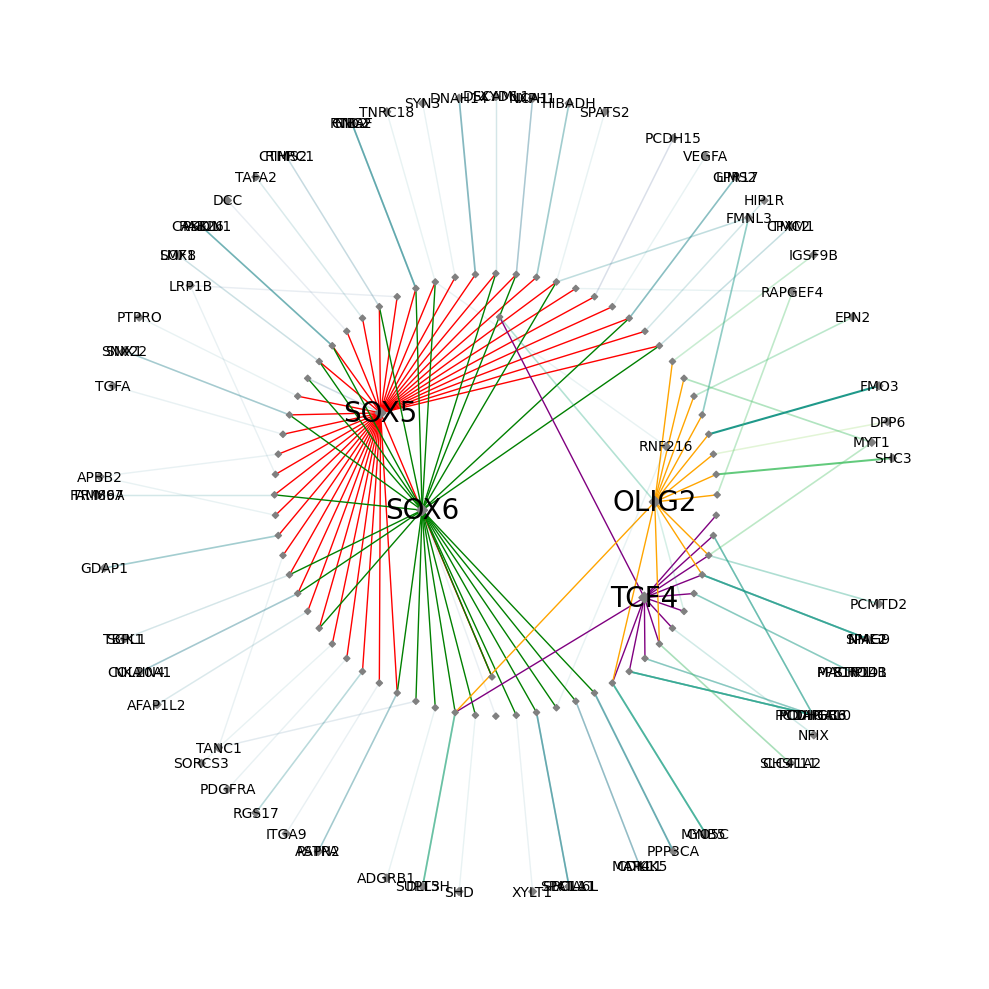

In [14]:
# To draw with networkx
plt.figure(figsize=(10,10))
plot_networkx(G_c, pos_c)

In [15]:
edge_tables_c = edge_tables_c.reset_index() #must reindex first!
del edge_tables_c['index']
# link_type column: R-G vs TF-R
edge_tables_c['link_type'] = ['R2G' if i==True else "TF2R" for i in edge_tables_c['source'].str.startswith('chr') ]

In [16]:
edge_tables_c

,source,target,color,width,color_rgb,color_alpha,link_type
0,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.000000,TF2R
1,SOX6,chr7:23299035-23299536,#008000ff,1,#008000,255.000000,TF2R
2,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.000000,TF2R
3,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.000000,TF2R
4,SOX6,chr7:23299035-23299536,#008000ff,1,#008000,255.000000,TF2R
...,...,...,...,...,...,...,...
295,chr2:159130318-159130819,TANC1,#306a8e23,1.066603,#306a8e,202.161572,R2G
296,chr4:40846477-40846978,APBB2,#26818e1a,1.01026,#26818e,200.000000,R2G
297,chr22:32616219-32616720,SYN3,#27808e1a,1.019504,#27808e,200.000000,R2G
298,chr12:62026313-62026814,TAFA2,#25858e2b,1.082572,#25858e,204.082969,R2G


In [17]:
links = pd.Series([ "-".join(row)  for i , row in edge_tables_c.loc[:,['source','target']].iterrows()])

In [18]:
idx = links.duplicated() # duplicates: keep first; graph needs one TF->R and one R->G

In [19]:
idx.sum() #32
edge_tables_c[idx]['source'].str.startswith('chr').value_counts() # 18 duplicate R-G; 14 duplicate TF-R

False    55
True     33
Name: source, dtype: int64

In [20]:
edge_tables_c_filter = edge_tables_c[~idx] # Drop duplicate edges; keep one-to-one

In [21]:
edge_tables_c_filter

,source,target,color,width,color_rgb,color_alpha,link_type
0,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.000000,TF2R
1,SOX6,chr7:23299035-23299536,#008000ff,1,#008000,255.000000,TF2R
6,SOX6,chr14:51989257-51989758,#008000ff,1,#008000,255.000000,TF2R
7,SOX5,chr14:51989257-51989758,#ff0000ff,1,#ff0000,255.000000,TF2R
11,SOX5,chr1:231021601-231022102,#ff0000ff,1,#ff0000,255.000000,TF2R
...,...,...,...,...,...,...,...
295,chr2:159130318-159130819,TANC1,#306a8e23,1.066603,#306a8e,202.161572,R2G
296,chr4:40846477-40846978,APBB2,#26818e1a,1.01026,#26818e,200.000000,R2G
297,chr22:32616219-32616720,SYN3,#27808e1a,1.019504,#27808e,200.000000,R2G
298,chr12:62026313-62026814,TAFA2,#25858e2b,1.082572,#25858e,204.082969,R2G


In [22]:
# For plotting: one region -> one gene
edge_tables_R2G = edge_tables_c_filter[edge_tables_c_filter['link_type'] == 'R2G']#182 rows × 7 columns
edge_tables_R2G['source'].duplicated().sum() # 13 regions map to multiple genes
idx3 = edge_tables_R2G['source'].duplicated() # duplicated(): first False, rest True
edge_tables_R2G_filter = edge_tables_R2G[~idx3] #169 rows × 7 columns

In [23]:
idx3.sum()

47

In [24]:
edge_tables_TF2R = edge_tables_c_filter[edge_tables_c_filter['link_type'] == 'TF2R']#186 rows × 7 columns

In [25]:
edge_tables_TF2R

,source,target,color,width,color_rgb,color_alpha,link_type
0,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.0,TF2R
1,SOX6,chr7:23299035-23299536,#008000ff,1,#008000,255.0,TF2R
6,SOX6,chr14:51989257-51989758,#008000ff,1,#008000,255.0,TF2R
7,SOX5,chr14:51989257-51989758,#ff0000ff,1,#ff0000,255.0,TF2R
11,SOX5,chr1:231021601-231022102,#ff0000ff,1,#ff0000,255.0,TF2R
...,...,...,...,...,...,...,...
145,SOX6,chr2:159130318-159130819,#008000ff,1,#008000,255.0,TF2R
146,SOX5,chr4:40846477-40846978,#ff0000ff,1,#ff0000,255.0,TF2R
147,SOX5,chr22:32616219-32616720,#ff0000ff,1,#ff0000,255.0,TF2R
148,SOX5,chr12:62026313-62026814,#ff0000ff,1,#ff0000,255.0,TF2R


In [26]:
edge_tables_TF2R['target'].isin(edge_tables_R2G_filter['source']).sum() #182

95

In [27]:
idx4 = edge_tables_TF2R['target'].isin(edge_tables_R2G_filter['source']) # TF-R targets must exist in R-G sources

In [28]:
edge_tables_TF2R_filter = edge_tables_TF2R[idx4]


In [29]:
edge_tables_R2G_filter[edge_tables_R2G_filter['source'].isin(['chr14:51989257-51989758'])]

,source,target,color,width,color_rgb,color_alpha,link_type
156,chr14:51989257-51989758,GNG2,#29798e1d,1.054934,#29798e,200.720524,R2G


In [30]:
edge_tables_filter = pd.concat([edge_tables_TF2R_filter,edge_tables_R2G_filter ],axis = 0).reset_index(drop = True)


In [31]:
edge_tables_filter

,source,target,color,width,color_rgb,color_alpha,link_type
0,SOX5,chr7:23299035-23299536,#ff0000ff,1,#ff0000,255.000000,TF2R
1,SOX6,chr7:23299035-23299536,#008000ff,1,#008000,255.000000,TF2R
2,SOX6,chr14:51989257-51989758,#008000ff,1,#008000,255.000000,TF2R
3,SOX5,chr14:51989257-51989758,#ff0000ff,1,#ff0000,255.000000,TF2R
4,SOX5,chr1:231021601-231022102,#ff0000ff,1,#ff0000,255.000000,TF2R
...,...,...,...,...,...,...,...
160,chr2:159130318-159130819,TANC1,#306a8e23,1.066603,#306a8e,202.161572,R2G
161,chr4:40846477-40846978,APBB2,#26818e1a,1.01026,#26818e,200.000000,R2G
162,chr22:32616219-32616720,SYN3,#27808e1a,1.019504,#27808e,200.000000,R2G
163,chr12:62026313-62026814,TAFA2,#25858e2b,1.082572,#25858e,204.082969,R2G


In [32]:
edge_tables_c.to_csv('./cytoscape/edge_tables_degree.txt',sep='\t',index=False)
edge_tables_filter.to_csv('./cytoscape/edge_tables_degree_filter.txt',sep='\t',index=False)
# edge_tables_filter_top3.to_csv('./cytoscape/edge_tables_filter_top3.txt',sep='\t',index=False)


In [33]:
node_tables_c

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
OLIG2,TF,OLIG2,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
SOX5,TF,SOX5,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
SOX6,TF,SOX6,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
TCF4,TF,TCF4,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
chr7:8387607-8388108,Region,chr7:8387607-8388108,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
SNX1,Gene,SNX1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
TRIM67,Gene,TRIM67,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
FMNL3,Gene,FMNL3,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255


In [34]:
node_tables_TF = node_tables_c[node_tables_c['group'] == 'TF' ]
node_tables_Region = node_tables_c[node_tables_c['group'] == 'Region' ]
node_tables_Gene = node_tables_c[node_tables_c['group'] == 'Gene' ]


In [35]:
node_tables_TF

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
OLIG2,TF,OLIG2,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
SOX5,TF,SOX5,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
SOX6,TF,SOX6,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255
TCF4,TF,TCF4,#808080ff,30,ellipse,20.0,#000000ff,#808080,255,#000000,255


In [36]:
node_tables_Region

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
chr7:8387607-8388108,Region,chr7:8387607-8388108,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr19:39497778-39498279,Region,chr19:39497778-39498279,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr12:15356762-15357263,Region,chr12:15356762-15357263,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr21:33116626-33117127,Region,chr21:33116626-33117127,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr16:1019385-1019886,Region,chr16:1019385-1019886,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
chr10:114173997-114174498,Region,chr10:114173997-114174498,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr11:134034801-134035302,Region,chr11:134034801-134035302,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255
chr6:43854127-43854628,Region,chr6:43854127-43854628,#808080ff,10,diamond,0.0,#000000ff,#808080,255,#000000,255


In [37]:
node_tables_Gene

,group,label,color,size,shape,font_size,font_color,color_rgb,color_alpha,font_color_rgb,font_color_alpha
label,,,,,,,,,,,
HIP1R,Gene,HIP1R,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
PCDHGA10,Gene,PCDHGA10,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
PAPPA,Gene,PAPPA,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
GDAP1,Gene,GDAP1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
CASKIN1,Gene,CASKIN1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
...,...,...,...,...,...,...,...,...,...,...,...
SNX1,Gene,SNX1,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
TRIM67,Gene,TRIM67,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255
FMNL3,Gene,FMNL3,#808080ff,15,ellipse,10.0,#000000ff,#808080,255,#000000,255


In [38]:
node_tables_TF['label'].duplicated().sum()#0
node_tables_Region['label'].duplicated().sum()#0
node_tables_Gene['label'].duplicated().sum()#0

0

In [39]:
node_tables_TF.index = node_tables_TF['label']
node_tables_Region.index = node_tables_Region['label']
node_tables_Gene.index = node_tables_Gene['label']

In [40]:
X_ACC = scplus_obj.X_ACC.copy() #141240 rows × 9282 columns
X_EXP = scplus_obj.X_EXP.copy().T #36601 rows × 9282 columns

In [41]:
metadata = scplus_obj.metadata_cell.copy()
metadata

,sample2,barcode2,celltype
TCGTTTCCAACTCGCG-1-7___cisTopic,GW20,TCGTTTCCAACTCGCG-1,MOL
CCTCCTGAGTTAGTTG-1-7___cisTopic,GW20,CCTCCTGAGTTAGTTG-1,OPC
CGTCCTAGTAACCTAG-1-1___cisTopic,GW12,CGTCCTAGTAACCTAG-1,OPC
CATCATGCAGGCCATT-1-6___cisTopic,GW17,CATCATGCAGGCCATT-1,OPC
GAAAGCCAGCTATTGA-1-5___cisTopic,GW16,GAAAGCCAGCTATTGA-1,MFOL
...,...,...,...
GTTAACCAGTAAGAAC-1-5___cisTopic,GW16,GTTAACCAGTAAGAAC-1,OPC
TACTTCGTCTGTTCAT-1-5___cisTopic,GW16,TACTTCGTCTGTTCAT-1,NPC
CACAAGCGTTGAGCCG-1-5___cisTopic,GW16,CACAAGCGTTGAGCCG-1,COP
TTGCGTCTCCATAAGC-1-5___cisTopic,GW16,TTGCGTCTCCATAAGC-1,OPC


In [42]:
(X_ACC.columns == X_EXP.columns).all()#True
(X_ACC.columns == metadata.index).all() #True

True

In [43]:
metadata['celltype'].value_counts()

OPC     3245
COP     2071
MFOL    1317
NPC      940
dIPC     907
MOL      802
Name: celltype, dtype: int64

In [44]:
##aggregate pseudobulk exprMat and accMat

def aggregate_X_simple(mat, metadata_df, method = 'sum'):

    celltype = list(metadata['celltype'].cat.categories)
    
    exprMat_ave = pd.DataFrame(index = mat.index,columns = celltype)
    
    for g in celltype:
        cellid = metadata_df[metadata_df['celltype'] == g].index
        size = len(cellid)

        if size >= 10:
            if method == "sum":
                mat_ave_sel = mat.loc[:,cellid].sum(axis = 1)
            elif method == "mean":
                mat_ave_sel = mat.loc[:,cellid].mean(axis = 1)
            else:
                print('wrong aggregate method ' + method)
                break
                
            exprMat_ave[g] = mat_ave_sel
        else:
            print('Error, group size < 10 at ' + g)


    if exprMat_ave.isna().sum().sum() != 0:
        print('NA found')

    return(exprMat_ave)

In [ ]:
exprMat = aggregate_X_simple(mat = X_EXP.copy(), metadata_df = metadata.copy(), method = 'mean') 
row_mean = exprMat.mean(axis=1)
row_std = exprMat.std(axis=1)
exprMat = exprMat.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0)      
#36601 rows × 6 columns

In [49]:
accMat = aggregate_X_simple(mat = X_ACC.copy(), metadata_df = metadata.copy(), method = 'mean')
row_mean = accMat.mean(axis=1)
row_std = accMat.std(axis=1)
accMat = accMat.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0)
#141240 rows × 6 columns

In [ ]:
de_markers_all = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/Oligo/oligo_marker_celltype_de.csv')
de_markers_all

In [51]:
de_markers_all['group'].value_counts()

NPC     4445
MFOL    1622
MOL     1325
COP      864
OPC      757
dIPC     462
Name: group, dtype: int64

In [52]:
cell_type_dict = {
        'NPC' : 'NPC',  
        'dIPC' : 'dIPC', 
        'OPC' : 'OPC',
        'COP' : 'COP',
        'MFOL' : 'MFOL',
        'MOL' : 'MOL',
}

In [53]:
(pd.Series(de_markers_all['group'].value_counts().index).isin(cell_type_dict.keys())).all()#True


True

In [54]:
de_markers_all_new = de_markers_all.copy()
de_markers_all_new['group'] = de_markers_all_new['group'].map(cell_type_dict)
de_markers_all_new['group'] = de_markers_all_new['group'].astype('category').cat.set_categories(
    ['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL'])

In [55]:
de_markers_all_new['group'].value_counts().sort_index()

NPC     4445
dIPC     462
OPC      757
COP      864
MFOL    1622
MOL     1325
Name: group, dtype: int64

In [56]:
(de_markers_all.index == de_markers_all_new.index).all() #True

True

In [57]:
bed_files_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/pycisTopic/Oligo/cistopic_data/region_sets/DARs_cell_type"
bed_files = glob.glob(os.path.join(bed_files_path, "*.bed"))

all_data = []
for bed_file in bed_files:
    celltype = os.path.basename(bed_file).replace('.bed', '')
    df_temp = pd.read_csv(bed_file, sep='\t', header=None)
    if df_temp.shape[1] >= 3:
        # chr, start, end
        df_temp = df_temp.iloc[:, :3]
        df_temp.columns = ['chr', 'start', 'end']
        # chr:start-end
        df_temp['peakid'] = df_temp['chr'] + ':' + df_temp['start'].astype(str) + '-' + df_temp['end'].astype(str)
        df_temp['celltype'] = celltype
        all_data.append(df_temp)


In [58]:
dar_table = pd.concat(all_data, ignore_index=True)

In [59]:
dar_table['celltype'] = dar_table['celltype'].astype('category').cat.set_categories(
    ['NPC', 'dIPC', 'OPC', 'COP', 'MFOL', 'MOL'])


In [60]:
dar_table['celltype'].value_counts().sort_index()

NPC     13207
dIPC    13789
OPC      6314
COP     10792
MFOL    14141
MOL     10634
Name: celltype, dtype: int64

In [61]:
cid = 'OPC'

In [62]:
(node_tables_TF['label'].isin(exprMat.index)).all() #True
(pd.Series(cid).isin(exprMat.columns)).all() #True
node_tables_TF['expr_value'] = exprMat.loc[node_tables_TF['label'],cid]

In [63]:
(node_tables_Gene['label'].isin(exprMat.index)).all() #True
(pd.Series(cid).isin(exprMat.columns)).all() #True
node_tables_Gene['expr_value'] = exprMat.loc[node_tables_Gene['label'],cid]

In [64]:
(node_tables_Region['label'].isin(accMat.index)).all() #True
(pd.Series(cid).isin(accMat.columns)).all() #True
node_tables_Region['acc_value'] = accMat.loc[node_tables_Region['label'],cid]

In [65]:
(pd.Series(cid).isin(de_markers_all_new['group'])).all() #True
flag = node_tables_TF['label'].isin(de_markers_all_new[de_markers_all_new['group'] == cid]['names'])
node_tables_TF['deg_label'] = node_tables_TF['label'][flag]
flag = node_tables_Gene['label'].isin(de_markers_all_new[de_markers_all_new['group'] == cid]['names'])
node_tables_Gene['deg_label'] = node_tables_Gene['label'][flag]
pos = np.where(de_markers_all_new[de_markers_all_new['group'] == cid]['names'].isin(node_tables_Gene['label']) )
node_tables_Gene['deg_label'].isna().sum() #928
node_tables_Gene['isDEG'] = ['No' if i == True else "Yes" for i in node_tables_Gene['deg_label'].isna()]


In [66]:
(pd.Series(cid).isin(dar_table['celltype'])).all() #True
flag = node_tables_Region['label'].isin(dar_table[dar_table['celltype'] == cid]['peakid']) #314

In [67]:
node_tables_Region['dar_label'] = node_tables_Region['label'][flag]#'"'+node_tables_Region['label'][flag]+'"'
node_tables_Region['dar_label'].isna().sum() #2539
node_tables_Region['isDAR'] = ['No' if i == True else "Yes" for i in node_tables_Region['dar_label'].isna()]

In [68]:
node_tables_c_filter = pd.concat([node_tables_TF,node_tables_Gene,node_tables_Region],axis = 0,)
node_tables_c_filter['celltype'] = 'OPC'
node_tables_c_filter = node_tables_c_filter.reset_index(drop=True)
node_tables_c_filter['label'].duplicated().sum()#0

0

In [69]:
#write node table
node_tables_c.to_csv('./cytoscape/node_tables_degree.txt',sep='\t',index=False)
node_tables_c_filter.to_csv('./cytoscape/node_tables_degree_filter.txt',sep='\t',index=False,na_rep = ' ')

In [ ]:
# export_to_cytoscape(G_c, pos_c,
#                     './cytoscape/OLIG2_SOX5_SOX6_TCF4.network.cyjs',
#                     pos_scaling_factor=200, size_scaling_factor=1)